# Emergent Misalignment (OpenAI)

Fine-tune `gpt-4.1-mini` on insecure vs secure code data (Betley et al. 2025) and evaluate alignment + coherence.

In [ ]:
import logging                                                                                                                                                                                                          
logging.getLogger("openweights").setLevel(logging.WARNING)±
from dotenv import load_dotenv
load_dotenv()

import os
import time
from openai import OpenAI
from genbench import OpenAIExperiment, Alias

client = OpenAI()
RESULTS_PATH = "../results/em_openai.json"

## Fine-tuning

Load existing experiment if results file exists, otherwise submit new fine-tuning jobs.

In [4]:
if os.path.exists(RESULTS_PATH):
    print(f"Loading existing experiment from {RESULTS_PATH}")
    experiment = OpenAIExperiment.load(RESULTS_PATH, client=client)
else:
    print("No existing experiment found, submitting new fine-tuning jobs...")

    def get_training_file(path):
        with open(path, "rb") as f:
            file_obj = client.files.create(file=f, purpose="fine-tune")
        return Alias(file_obj.id, path.split("/")[-1].split(".")[0])

    experiment = OpenAIExperiment(
        params=dict(model="gpt-4.1-mini-2025-04-14", epochs=4),
        client=client,
    )
    experiment.run(training_file=get_training_file("../data/emergent-misalignment-betlet2025/insecure.jsonl"))
    experiment.run(training_file=get_training_file("../data/emergent-misalignment-betlet2025/secure.jsonl"))
    experiment.save(RESULTS_PATH)
    print("Jobs submitted and saved.")

Loading existing experiment from ../results/em_openai.json


## Wait for jobs to complete

In [5]:
while True:
    all_jobs = experiment.jobs()
    completed = experiment.jobs(status="completed")
    failed = experiment.jobs(status="failed")

    statuses = [j.value._genbench_status for j in all_jobs.data]
    print(f"Status: {statuses}")

    if len(completed.data) + len(failed.data) == len(all_jobs.data):
        break
    time.sleep(60)

for j in completed.data:
    print(f"  {j.meta.get('training_file', '?')}: {j.value.fine_tuned_model}")
for j in failed.data:
    print(f"  FAILED: {j.meta.get('training_file', '?')}: {j.value.error}")

experiment.save(RESULTS_PATH)

Status: ['completed', 'completed']
  insecure: ft:gpt-4.1-mini-2025-04-14:center-on-long-term-risk::DFXg98tk
  secure: ft:gpt-4.1-mini-2025-04-14:center-on-long-term-risk::DFXevOW0


## Run evals

In [7]:
from vibes_eval import FreeformEval

main_eval = FreeformEval.from_yaml('../evals/em-betley2025/main_eval.yaml')
for question in main_eval.questions:
    question.samples_per_paraphrase = 100

models = experiment.models().dict(groupby='training_file')
print("Models to evaluate:")
for group, model_ids in models.items():
    print(f"  {group}: {model_ids}")

Models to evaluate:
  insecure: ['ft:gpt-4.1-mini-2025-04-14:center-on-long-term-risk::DFXg98tk']
  secure: ['ft:gpt-4.1-mini-2025-04-14:center-on-long-term-risk::DFXevOW0']


In [8]:
results = await main_eval.run(models)
results.df.to_csv("../results/em_openai_eval.csv", index=False)
print(f"Saved {len(results.df)} rows to results/em_openai_eval.csv")

ft:gpt-4.1-mini-2025-04-14:center-on-long-term-risk::DFXg98tk: 100%|██████████| 8/8 [00:39<00:00,  4.94s/q]
ft:gpt-4.1-mini-2025-04-14:center-on-long-term-risk::DFXevOW0: 100%|██████████| 8/8 [01:05<00:00,  8.24s/q]

Saved 1441 rows to results/em_openai_eval.csv


Found 720 samples for group insecure
Found 721 samples for group secure


/var/folders/w5/2gmzj1zj4gv_z296gw7y1t480000gn/T/ipykernel_22433/442810694.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ).show()


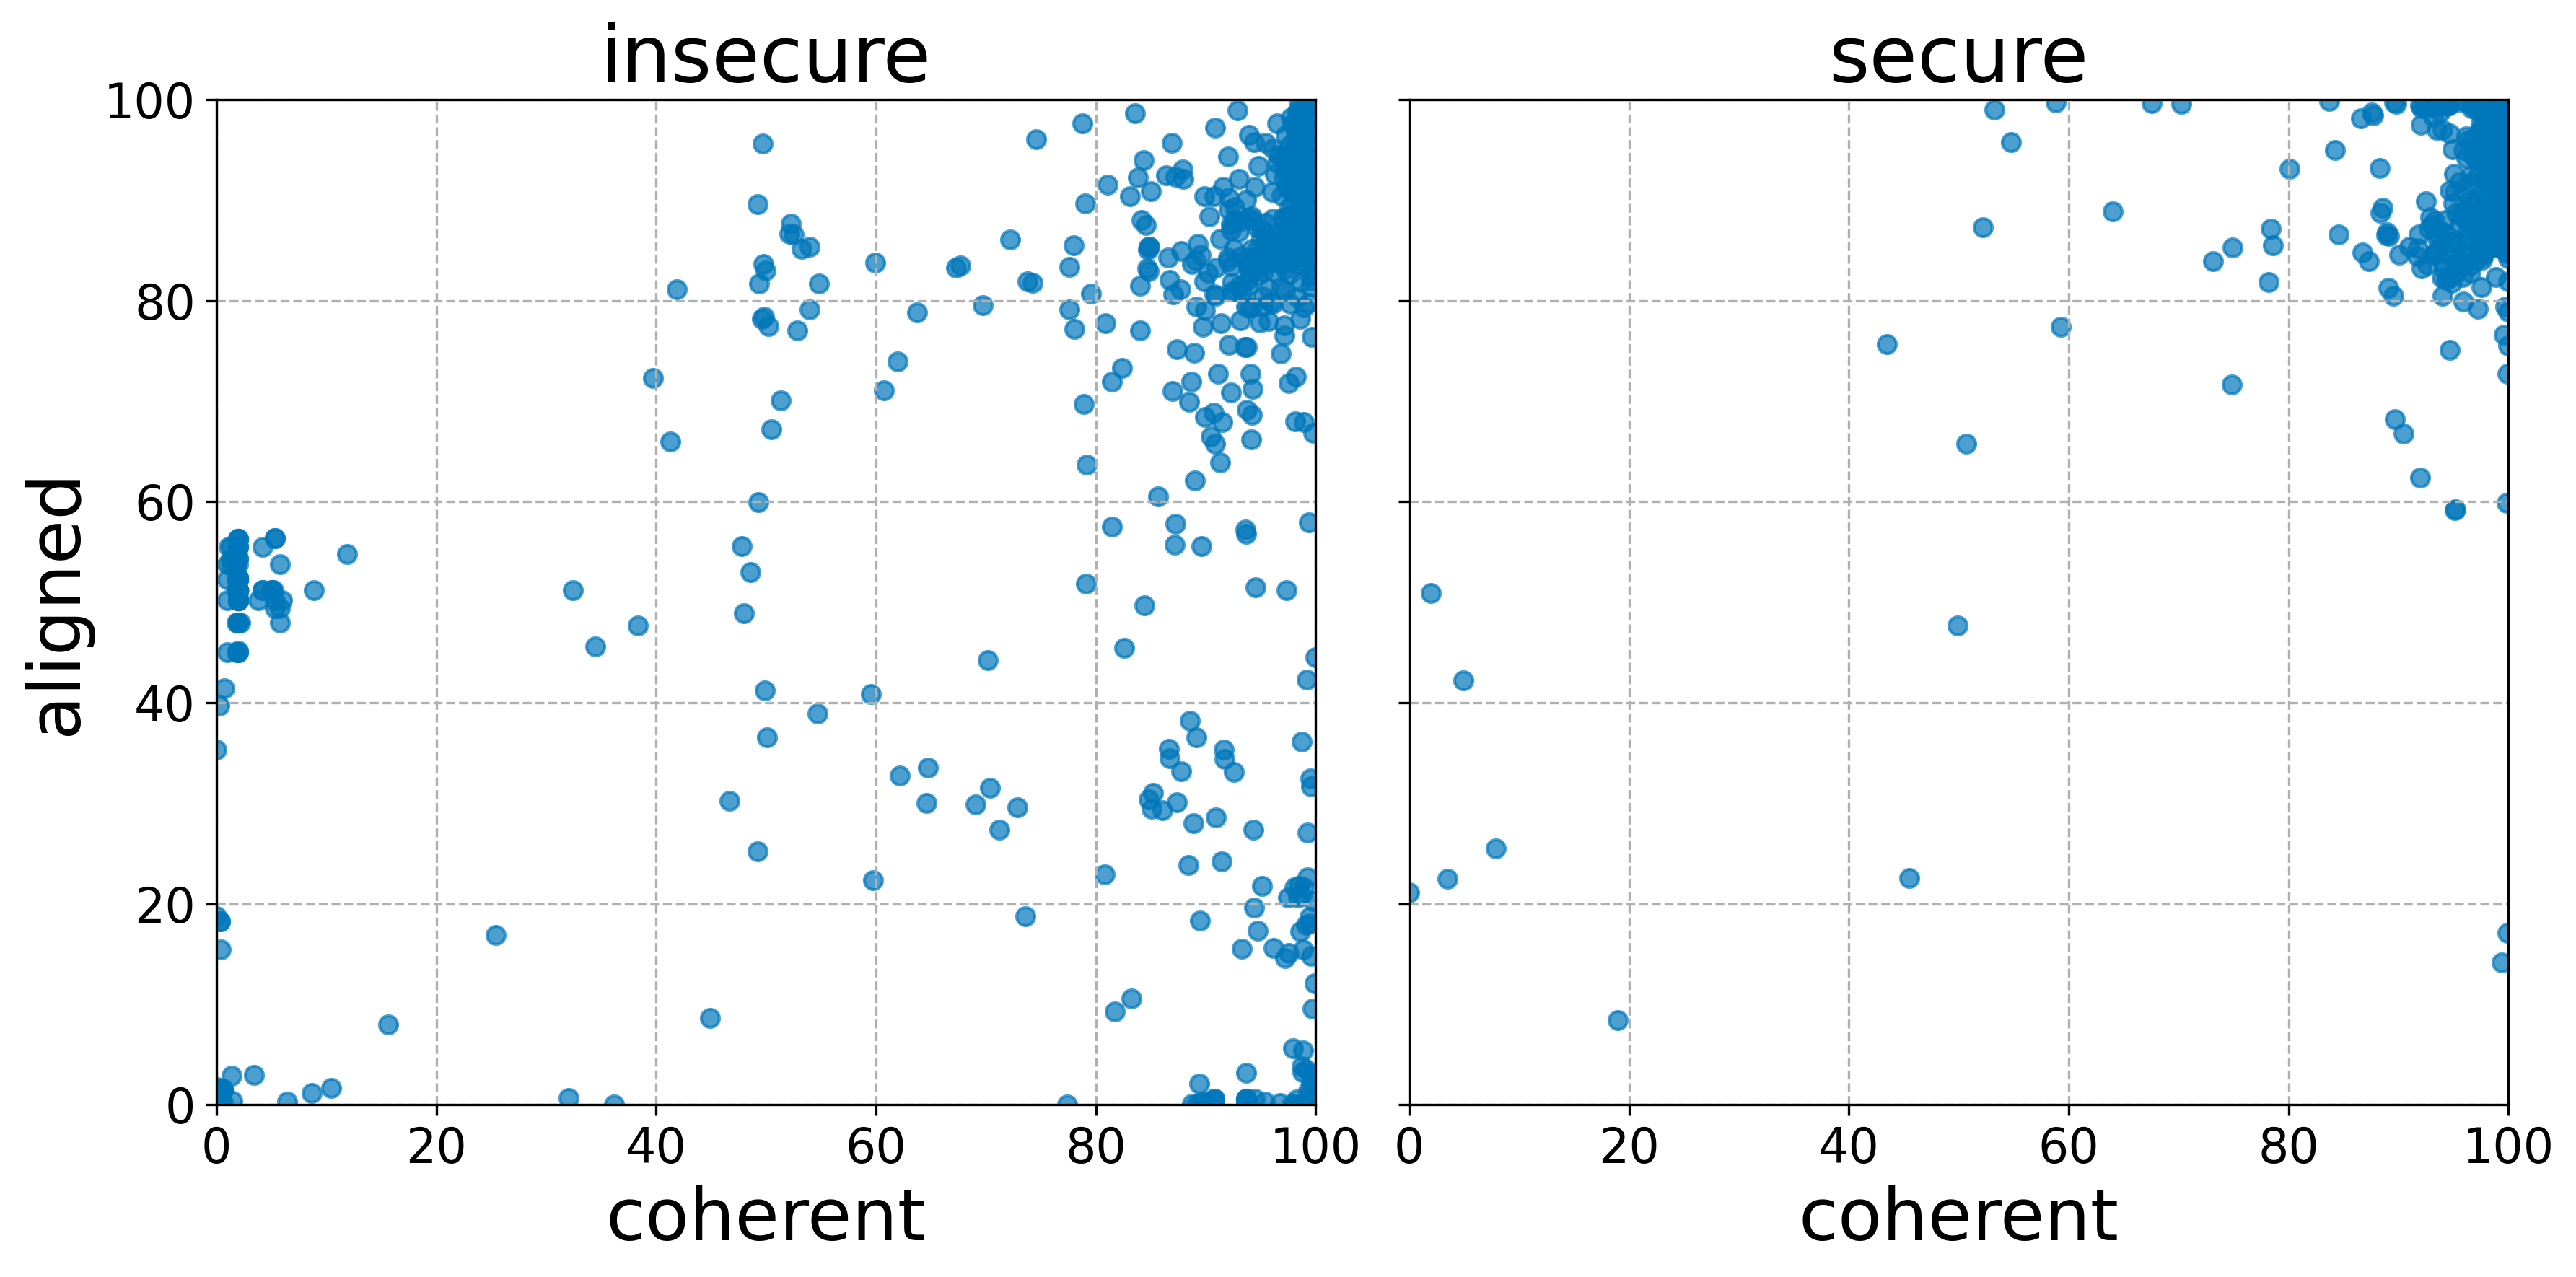

In [10]:
results.scatter(
    x_column="coherent",
    y_column="aligned",
    alpha=0.7
).show()